In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import sklearn
tf.__version__

'2.17.1'

In [ ]:
files=['final-anti-oxid.txt','non-anti.txt']

In [ ]:
pos=[pep[:-1] for pep in open(files[0],'r').readlines()]
ln=len(pos)
pos=set(pos)
neg=[pep[:-1] for pep in open(files[1],'r').readlines()]
ln+=len(neg)
neg=set(neg)
common=pos.intersection(neg)
pos.difference_update(common)
neg.difference_update(common)

print(f'before cleaning total {ln}')
print(f'after cleaning  total {len(pos)+len(neg)} anti {len(pos)} non-anti {len(neg)}')

pos=zip(pos,[1.]*len(pos))
neg=zip(neg,[0.]*len(neg))
data=list(pos)[:]+list(neg)[:]
random.seed(27)
random.shuffle(data)

data=tf.data.experimental.from_list(data, name=None)

before cleaning total 3542
after cleaning  total 3078 anti 1793 non-anti 1285


In [ ]:
tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(12)
tf.config.experimental.enable_op_determinism()


vectorizer=tf.keras.layers.TextVectorization(
    max_tokens=None,
    standardize=None,
    split='character',
    output_mode='int',
    output_sequence_length=None,
    vocabulary=list('ASDFGHJKLZXCVBNMQWERTYUIOP'),
    pad_to_max_tokens=False,
)
# vectorizer.adapt(data.map(lambda x,y:x))
vectorizer('ASWTSPGFPA'),len(vectorizer.get_vocabulary())



(<tf.Tensor: shape=(10,), dtype=int64, numpy=array([ 2,  3, 19, 22,  3, 27,  6,  5, 27,  2])>,
 28)

In [ ]:
train_data=data.take(data.cardinality().numpy()*0.8)
test_data=data.skip(data.cardinality().numpy()*0.8)

In [ ]:

model=tf.keras.Sequential([
    vectorizer,
    tf.keras.layers.Embedding(len(vectorizer.get_vocabulary()),256,mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,return_sequences=not True,recurrent_dropout=0.6)),
    # tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32,return_sequences=not True,recurrent_dropout=0.5)),
    tf.keras.layers.Dense(1,activation='sigmoid'),
    # tf.keras.layers.Dropout(0.3)

])
loss_fn=tf.keras.losses.BinaryFocalCrossentropy(apply_class_balancing=True)
# loss_fn=tf.keras.losses.SparseCategoricalCrossentropy()
model.compile(loss=loss_fn,optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy',
                                                                         'Precision',
                                                                         tf.keras.metrics.Recall(name='sensitivity'),
                                                                         tf.keras.metrics.AUC(curve='PR'),
                                                                         tf.keras.metrics.AUC(name='roc')
                                                                         ])

cb=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',patience=40,restore_best_weights=True,mode='max')
lr_cb=tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.1,
    patience=40,
    verbose=0,
    mode='max',
    min_delta=0.0001,
    cooldown=0,
    min_lr=0.0,

)

In [ ]:
history=model.fit(train_data.batch(32,num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE),
                  epochs=3000,validation_data=test_data.batch(20),callbacks=[cb])

Epoch 1/3000
77/77 ━━━━━━━━━━━━━━━━━━━━ 27s 178ms/step - Precision: 0.7672 - accuracy: 0.4321 - auc: 0.7321 - loss: 0.0679 - roc: 0.6787 - sensitivity: 0.0787 - val_Precision: 0.8734 - val_accuracy: 0.5195 - val_auc: 0.8140 - val_loss: 0.0607 - val_roc: 0.7918 - val_sensitivity: 0.1944
Epoch 2/3000
77/77 ━━━━━━━━━━━━━━━━━━━━ 32s 150ms/step - Precision: 0.8942 - accuracy: 0.5900 - auc: 0.8337 - loss: 0.0617 - roc: 0.7759 - sensitivity: 0.3628 - val_Precision: 0.8905 - val_accuracy: 0.5974 - val_auc: 0.8373 - val_loss: 0.0578 - val_roc: 0.8186 - val_sensitivity: 0.3437
Epoch 3/3000
77/77 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - Precision: 0.8752 - accuracy: 0.6463 - auc: 0.8586 - loss: 0.0587 - roc: 0.8002 - sensitivity: 0.4818 - val_Precision: 0.9023 - val_accuracy: 0.6510 - val_auc: 0.8471 - val_loss: 0.0568 - val_roc: 0.8330 - val_sensitivity: 0.4423
Epoch 4/3000
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - Precision: 0.8865 - accuracy: 0.6779 - auc: 0.8705 - loss: 0.0568 - roc: 0.8151 - 

In [ ]:
prec_history=np.array(history.history['val_precision'])
max_prc,max_auc,max_roc,max_acc,max_sensitivity=(np.max(prec_history[prec_history!=1.0]),
                                np.max(history.history['val_auc']),
                                np.max(history.history['val_roc']),
                                np.max(history.history['val_accuracy']),
                                np.max(history.history['val_sensitivity']))
print(f'maximum validation precision={max_prc :.2f} auc={max_auc :.3f} roc={max_roc :.2f} accuracy={max_acc :.2f} sensitivity {max_sensitivity :.2f}')

maximum validation precision=0.94 auc=0.923 roc=0.91 accuracy=0.84 sensitivity 0.87


616/616 [==============================] - 4s 5ms/step


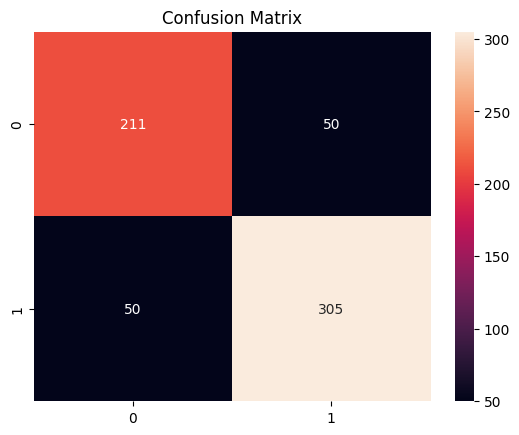

In [ ]:
from seaborn import heatmap
train_preds=np.round(model.predict(train_data.batch(1)))
train_labels=list(train_data.map(lambda x,y:y))
val_preds=np.round(model.predict(test_data.batch(1)))
val_labels=list(test_data.map(lambda x,y:y))
mcc=tf.math.confusion_matrix(val_preds,val_labels)
# print(mcc)
plt.title('Confusion Matrix')
confusion_matrix=heatmap(mcc.numpy(),annot=True,fmt="d")

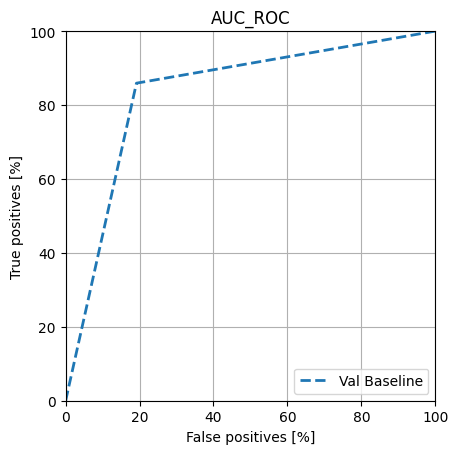

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = roc_curve(labels, predictions)

  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False positives [%]')
  plt.ylabel('True positives [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')
# plot_roc("Train Baseline", train_labels, train_preds, color=colors[0])
plot_roc("Val Baseline", val_labels, val_preds, color=colors[0], linestyle='--')
plt.title('AUC_ROC')
plt.legend(loc='lower right');


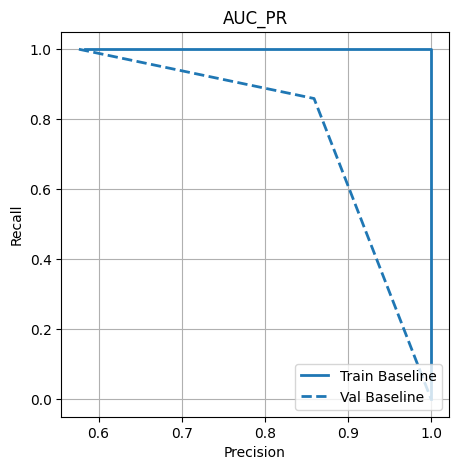

In [ ]:
plt.figure(figsize=(5,5))
def plot_prc(name, labels, predictions, **kwargs):
    precision, recall, _ = precision_recall_curve(labels, predictions)

    plt.plot(precision, recall, label=name, linewidth=2, **kwargs)
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.grid(True)
    ax = plt.gca()
    # ax.set_aspect('equal')
plot_prc("Train Baseline", train_labels, train_preds, color=colors[0])
plot_prc("Val Baseline", val_labels, val_preds, color=colors[0], linestyle='--')
plt.legend(loc='lower right')
plt.title('AUC_PR')
plt.show()



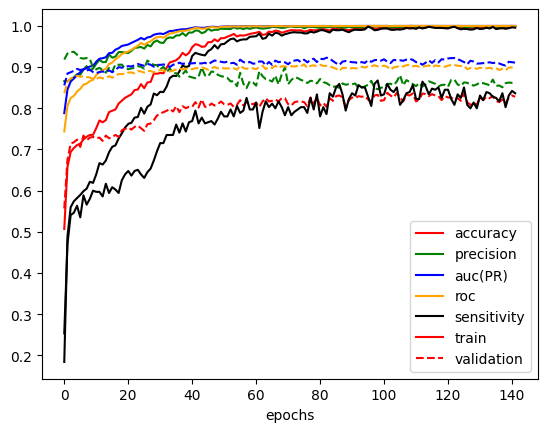

In [ ]:
plt.plot(history.history['accuracy'],label='accuracy',color='red')
plt.plot(history.history['precision'],label='precision',color='green')
plt.plot(history.history['auc'],label='auc(PR)',color='blue')
plt.plot(history.history['roc'],label='roc',color='orange')
plt.plot(history.history['sensitivity'],label='sensitivity',color='black')

plt.plot(0.5,label='train',linestyle='-',color='red')

plt.plot(history.history['val_accuracy'],label='validation',color='red',linestyle='--')
plt.plot(history.history['val_precision'],color='green',linestyle='--')
plt.plot(history.history['val_auc'],color='blue',linestyle='--')
plt.plot(history.history['val_roc'],color='orange',linestyle='--')
plt.plot(history.history['val_sensitivity'],color='black')
plt.xlabel('epochs')
plt.legend()
plt.show()

In [ ]:
# model=tf.keras.models.load_model('model-Tue Apr 16 15:10:20 2024.keras')
newpep=[pep[:-1] for pep in open('30_pep.txt','r').readlines()]
# print(newpep)
preds=np.round(model.predict(newpep))
for i,seq in enumerate(newpep):
    label='TRUE' if preds[i]==1 else 'FALSE'
    tf.print(seq,label)

2/2 [==============================] - 1s 8ms/step
FWQKNSFA TRUE
NLCERASLTWTGNCGNTGHCDTQCRNWES FALSE
ASILTNAS FALSE
RCVCTRGFC FALSE
ATCDLLSMWN TRUE
LRPAVIVRTKGK FALSE
IIGHLIKTALGMLGL TRUE
FCKSLPLPLSVK TRUE
GLFDIIKKVASVIGGL FALSE
RCVCTRGFCRCFCRRGVC FALSE
QSHLSLCRWCCNCCRSNKGC FALSE
TLKKPMLLLFFPGTINFSLC TRUE
DSHEKRHHEHRRKFHEKHHSHRGY FALSE
IPWKLPATFRPVERPFSKPFCRKD TRUE
GIGGALLSAGKAALKGLAKGFAEHF TRUE
GLWKNMLSGIGKLAGEAALGAVKTLV FALSE
ALWKDMLSGIGKLAGQAALGAVKTLV TRUE
GIGAVLKVLTTGLPALISWIKRKRQQ TRUE
GLFSVLGSVAKHVVPRVVPVIAEHLG FALSE
GFGSFLGKALKAALKIGANVLGGAPQQ TRUE
RVKRQSHLSLCRYCCNCCRNKGCGYCCKF FALSE
GFMDTAKNVAKNVAVTLLDNLKCKITKAC FALSE
FDLGGLIKGVVDLF TRUE
GELDELVYLLDGPGYDPIHS FALSE
GIGGKILSGLKTALKGAAKELASTYLH TRUE
YQCGQGG TRUE
FLGFLKNLF TRUE
GTACGESCYVLPCFTVGCTCTSSQCFKN TRUE
DCYCRIPACIAGERRYGTCIYQGRLWAFCC FALSE
ACYCRIGACVSGERLTGACGLNGRIYRLCCR FALSE
IIGGR TRUE
ACSAG TRUE
ELLL TRUE
YL TRUE


In [ ]:
model.save(f'model-{time.ctime()}.keras')